In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PRIORS = ["weakly", "flat", "lognormal_gamma"]
PRIOR_LABELS = {"flat": "Flat", "weakly": "Normal/Log-Normal", "lognormal_gamma": "Log-normal γ"}
SAMPLERS = ["rwmh", "mala"]

def load_summaries():
    data = {}
    for sampler in SAMPLERS:
        data[sampler] = {}
        for prior in PRIORS:
            path = f"Stats/posterior_summary_base_cutoff_{prior}_{sampler}.csv"
            data[sampler][prior] = pd.read_csv(path, index_col=0)
    return data

data = load_summaries()
data["rwmh"]["flat"]

,display_name,mean,sd,median,ci_lower,ci_upper,true
log_phi,phi,3.606007e-18,2.396452e-18,3.193653e-18,4.403595e-19,8.019262e-18,2.060000e-18
gamma,gamma,3.286134e+00,4.673024e-01,3.257927e+00,2.585548e+00,4.190420e+00,2.500000e+00
log_eta,eta,7.554939e-18,2.352475e-18,7.848999e-18,3.325595e-18,1.083457e-17,1.000000e-17
delta,delta,3.695234e+00,1.434578e-01,3.696556e+00,3.445887e+00,3.925273e+00,3.700000e+00


In [22]:
def plot_ci_comparison(sampler: str, data: dict):
    # get parameter list from first available df
    sample_df = data[sampler][PRIORS[0]]
    params = list(sample_df.index)          # e.g. log_phi, gamma, log_eta, delta
    display_names = list(sample_df["display_name"])

    n_params = len(params)
    n_priors = len(PRIORS)
    colors = ["#4C72B0", "#DD8452", "#55A868"]

    fig, axes = plt.subplots(1, n_params, figsize=(5 * n_params, 5))
    if n_params == 1:
        axes = [axes]

    for ax, param, dname in zip(axes, params, display_names):
        for k, (prior, color) in enumerate(zip(PRIORS, colors)):
            df = data[sampler][prior]
            row = df.loc[param]
            median = row["median"]
            lo = row["ci_lower"]
            hi = row["ci_upper"]
            true_val = row["true"]

            ax.errorbar(
                x=k,
                y=median,
                yerr=[[median - lo], [hi - median]],
                fmt="o",
                color=color,
                capsize=6,
                capthick=1.5,
                markersize=6,
                label=PRIOR_LABELS[prior],
            )

        # true value line
        if true_val is not None and not np.isnan(float(true_val)):
            ax.axhline(float(true_val), color="black", linestyle="--", linewidth=1, label="True value")

        ax.set_title(dname, fontsize=16)
        ax.set_xticks([])
        ax.tick_params(labelsize=10)
        ax.set_ylabel("Posterior value", fontsize=16)

    # shared legend from last axis
    handles, labels = axes[-1].get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        if l not in seen:
            seen[l] = h
    fig.legend(seen.values(), seen.keys(), loc="upper center", ncol=n_priors + 1,
               fontsize=14, bbox_to_anchor=(0.5, 1.02))

    fig.suptitle(f"90% Credible Intervals — {sampler.upper()}", fontsize=18, y=1.06)
    plt.tight_layout()
    plt.savefig(f"Figures/{sampler}_cutoff_prior.png", dpi = 600)

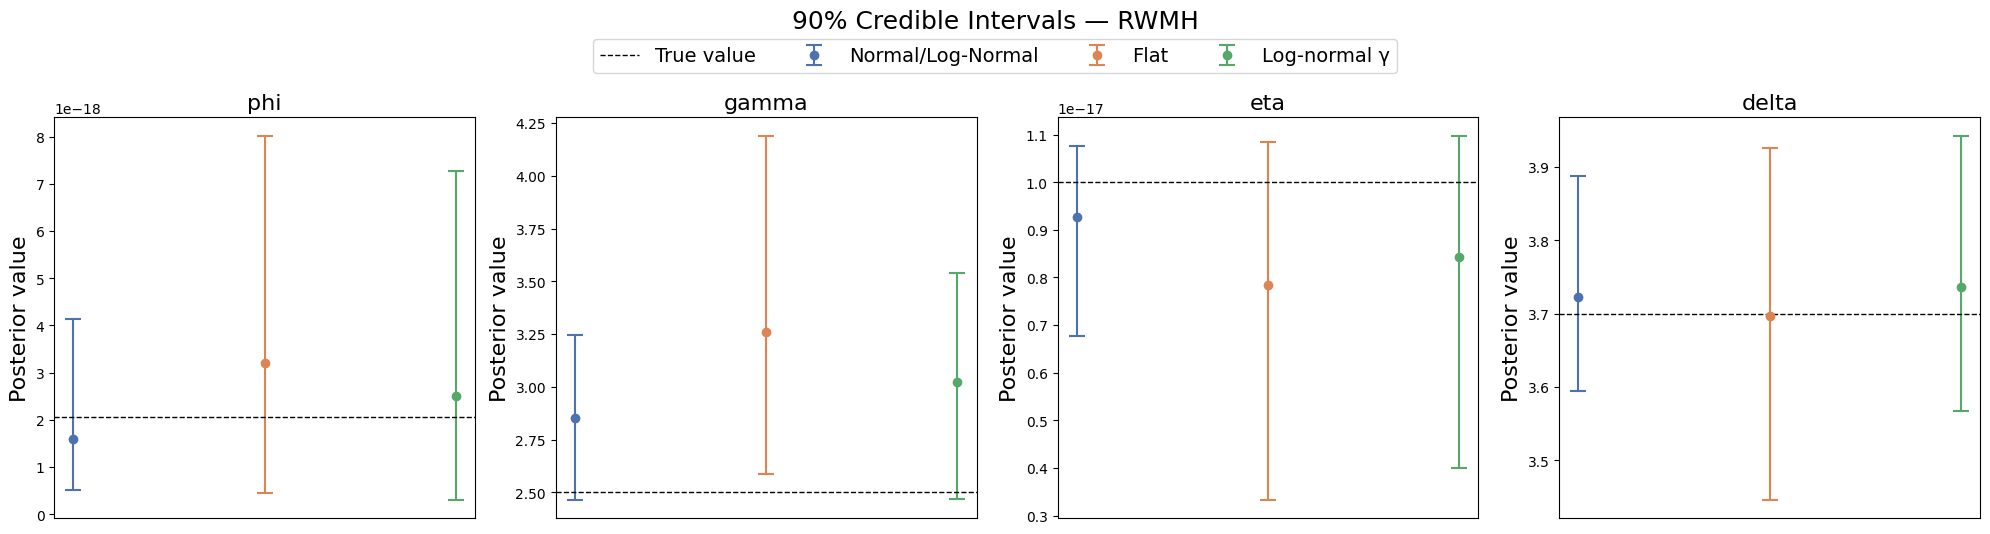

In [23]:
plot_ci_comparison("rwmh", data)

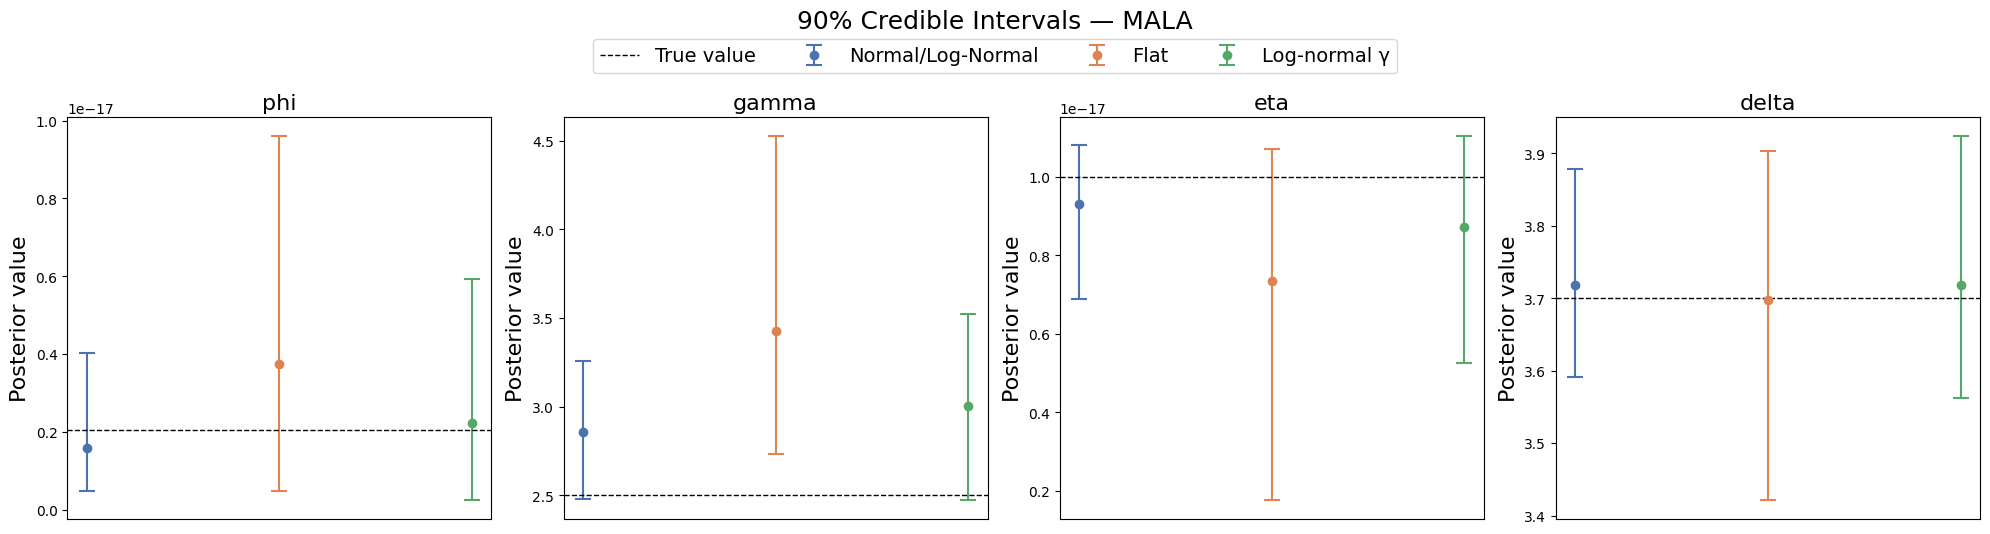

In [25]:
plot_ci_comparison("mala", data)